<a href="https://colab.research.google.com/github/GalkiNeS/numercial_methods/blob/main/%D0%A7%D0%98%D0%A1%D0%9B%D0%95%D0%9D%D0%9D%D0%90%D0%AF_%D0%98%D0%9D%D0%A2%D0%95%D0%A0%D0%9F%D0%9E%D0%9B%D0%AF%D0%A6%D0%98%D0%AF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №1: "Численная интерполяция"
Галкин Никита Сергеевич, группа Б24-201

Цель: построить численную интерполяцию функции $y = f(x)$ на отрезке $[a, b]$ и оценить погрешность в точках $x^*$, не совпадающих с узлами интерполяции

Методы:
1. Полином Лагранжа:

$$L_{n-1}(x) = \sum_{i = 0}^{n} {y_i} l_i(x),$$

где $y_i = f(x_i)$, $l_i(x) = \prod_{0 = j \neq i}^{n} {\frac{x - x_j}{x_i - x_j}}$ - базисные полиномы.

Если $f(x) \in C^n[a, b]$, то справедлива оценка погрешности интерполяции:
$$\max_{x \in [a, b]}{||f(x) - L_{n-1}(x)||} \le \frac{M_n}{n!}\max_{x \in [a, b]}{|\omega_n(x)|},$$
где $M_n = \max||f^{(n)}(x)||$, $\omega_n = \prod_{j = 0}^{n - 1} {(x - x_j)}$.

2. полином Эрмита:

$$H_{2n-1}(x) = \sum_{i = 0}^{n}\left\{ y_i[1 -2(x - x_i)l'_i(x_i)]l^2_i(x) + y'_i[x - x_i]l^2_i(x) \right\},$$

где $l'_i(x_i) = \sum_{0 = i \neq j}^{n} \frac{1}{x_j - x_i}$ - первая производная базисных полиномов Лагранжа.

Если $f(x) \in C^{2n}[a, b]$, то справедлива оценка погрешности интерполяции:
$$\max_{x \in [a, b]}{||f(x) - H_{2n-1}(x)||} \le \frac{M_{2n}}{(2n)!}\max_{x \in [a, b]}{\omega^2_n(x)},$$
где $M_{2n} = \max||f^{(2n)}(x)||$, $\omega^2_{n-1} = \prod_{j = 0}^{n-1} {(x - x_j)^2}$.

3. Эквидистантная сетка.

Оценка ошибки для полинома Лагранжа:
$$\max_{x \in [a, b]}{||R_{L_{n-1}}||} \le \frac{M_n}{n}h^{n},$$
где h - расстояние между узлами.

Оценка ошибки для полинома Эрмита:
$$\max_{x \in [a, b]}{||R_{H_{2n-1}}||} \le \frac{M_{2n} ((n-1)!)^2}{(2n)!}h^{2n},$$
4. Неэквидистантная сетка c набором узлов $\{x_i\}_{i = 0}^{n}$, при котором

$$\min_{\{x_i\}_{i = 0}^{n}}\{\max_{x \in [a, b]}{|\omega_{n+1}(x)|}\}.$$

Решение - полиномы Чебышева, определённые на $x \in [-1, 1]$:

$$T_n(x) = \cos(n\arccos(x)),$$
$$T_{n+1}(x) = 2xT_n(x) - T_{n-1}(x).$$

Растягивая $[-1, 1] \rightarrow [a, b]$, находим нули полиномов:

$$x_k = 0.5(a+b) + 0.5(b-a)\cos{\frac{2k + 1}{2n}\pi},$$

где $k = \overline{0, n-1}$.

Оценка минимальной ошибки полинома Лагранжа:

$$\max_{x \in [a, b]}{||R_{L_{n-1}}||} \le \frac{M_n}{n!}\frac{(b - a)^n}{2^{2n}}.$$

Оценка минимальной ошибки полинома Эрмита:

$$\max_{x \in [a, b]}{||R_{H_{2n-1}}||} \le \frac{M_{2n}}{(2n)!}\frac{(b - a)^{2n}}{2^{4n-2}}.$$

Результаты:
1. График сравнения функции y = f(x) и полученных численных решений для равномерного разбиения

2. График сравнения функции y = f(x) и полученных численных решений для неравномерного разбиения

3. Значения погрешностей интерполяции

Выводы:
1. Феномен Рунге демонстрирует недостаток полиномиальной интерполяции на эквидистантной сетке. При приближении к границам интервала  расстояния от точек, в которых вычисляется ошибка, до узлов интерполяции увеличиваются. С ростом $n$ график численного решения начинает совершать высокоамплитудные осцилляции на краях отрезка, что вносит большой вклад в ошибку.
2. Узлы Чебышёва полностью нивелируют феномен Рунге. Они сконцентрированы ближе к крайним точкам интервала: проекции середин дуг полуокружности, описанной вокруг интервала интерполяции, из-за кривизны окажутся ближе друг к другу, чем в центре. Благодаря этому минимизируется максимальное значение функции погрешности на всем интервале, и численное решение равномерно приближается к истинной кривой.


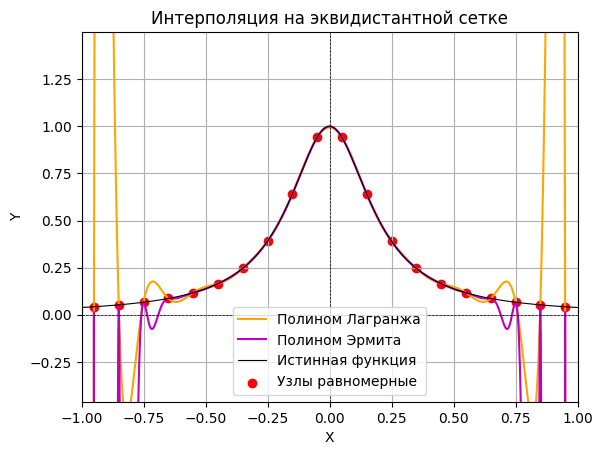

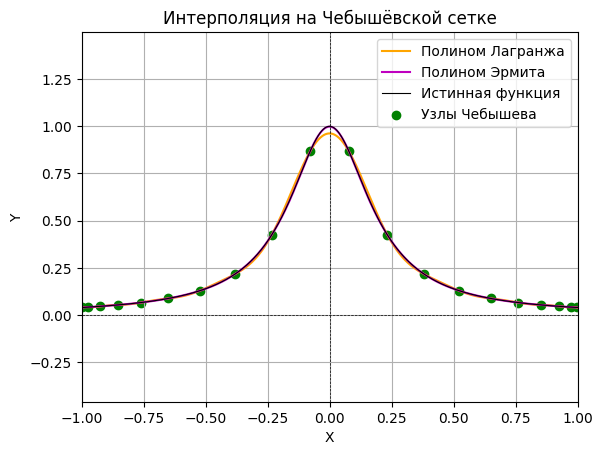

Максимальное отклонение на равномерной сетке. Лагранж: 159.41852430427386, Эрмит: 660770.9131842217
Максимальное отклонение на узлах Чебышёва: Лагранж: 0.03758185458921959, Эрмит: 0.0014124311749857954


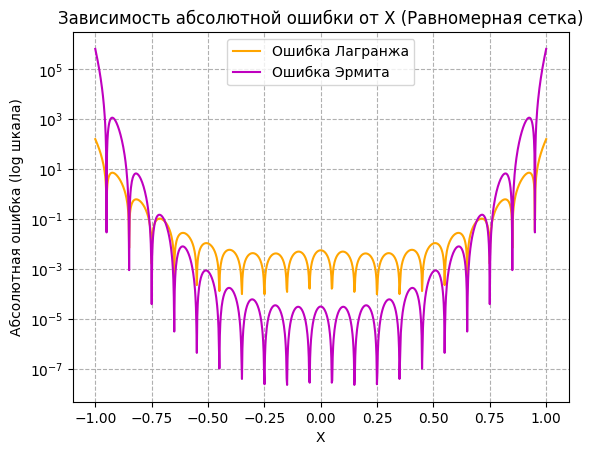

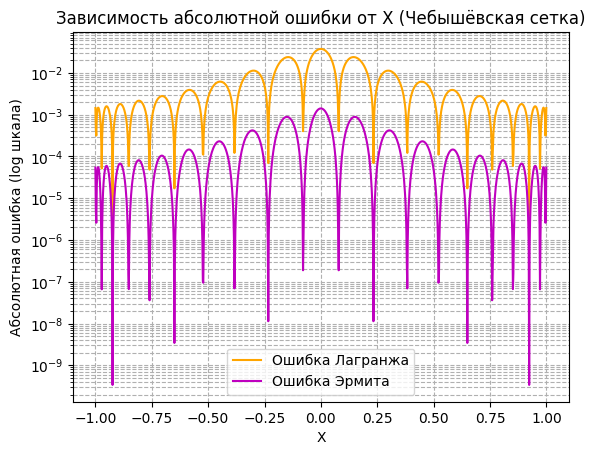

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

def f(x):
  y = 1/(1+25*x**2)
  # y = np.abs(x)
  # y = np.sin(1/x)
  # y = np.sin(x**2)
  return y

def der_f(x):
  der_y = -50*x/(1 + 25*x**2)**2 # y = 1/(1+25*x**2)
  # der_y = np.asanyarray(np.sign(x), dtype=float)
  # der_y = -1/x**2*np.cos(1/x)
  # der_y = 2*x*np.cos(x**2)
  return der_y

def lagrange(Xp, Yp): # степень n - 1
    def P(i, x):
        """Вычисляет базовый полином Лагранжа Pi(x)"""
        result = 1
        for j in range(len(Xp)): # так как j!=i
            if j != i:
                result *= (x - Xp[j]) / (Xp[i] - Xp[j])
        return result
    def L(x):
        """Вычисляет интерполирующий полином L(x)"""
        result = 0
        for i in range(len(Yp)):
            result += Yp[i] * P(i, x)
        return result
    return L

def Hermit(Xp, Yp, der_Yp): # степень 2n - 1
    def P(i, x):
        """Вычисляет базовый полином Лагранжа Pi(x)"""
        result = 1
        for j in range(len(Xp)): # так как j!=i
            if j != i:
                result *= (x - Xp[j]) / (Xp[i] - Xp[j])
        return result
    def der_lagrange(i, x):
        """Вычисляет первую производную базовых полиномов Лагранжа P'i(xi)"""
        result = 0
        for j in range(len(Xp)): # так как j!=i
            if j != i:
                result += 1 / (Xp[i] - Xp[j])
        return result
    def H(x):
        """Вычисляет интерполирующий полином H(x)"""
        result = 0
        for i in range(len(Yp)):
            result += Yp[i]*(1 - 2*(x - Xp[i])*der_lagrange(i, Xp[i]))*P(i, x)**2 + der_Yp[i]*(x - Xp[i])*P(i, x)**2
        return result
    return H

a = -1
b = 1
c = 20 # кол-во интервалов
h = (b - a)/c # шаг сетки равномерно распределенных узлов

# график истинной функции
X = np.linspace(a, b, 1000)
Y = f(X)
# fig, ax = plt.subplots()
# ax.plot(X, Y, color='black', linewidth=1)
# ax.set_title('Истинная функция')
# ax.set_xlabel('X')
# ax.set_ylabel('Y')
# plt.grid(True)
# plt.show()

# массив равномерных узлов сетки, в которых вычисляется полином
Xp = [a + h/2]
for x in range(1, c):
    Xp += [Xp[0] + x*h]
Yp = [f(x) for x in Xp]
der_Yp = [der_f(x) for x in Xp]

# Значеня интерполяционного полинома Лагранжа
polynom_L = lagrange(Xp, Yp)
Y_interp_L = [polynom_L(x) for x in X]

# Значеня интерполяционного полинома Эрмита
polynom_H = Hermit(Xp, Yp, der_Yp)
Y_interp_H = [polynom_H(x) for x in X]

plt.plot(X, Y_interp_L, label='Полином Лагранжа', color='orange')
plt.plot(X, Y_interp_H, label='Полином Эрмита', color='m')
plt.plot(X, Y, label='Истинная функция', color='black', linewidth=0.8)
plt.scatter(Xp, Yp, color='r', label='Узлы равномерные')
plt.title('Интерполяция на эквидистантной сетке')
plt.xlabel('X')
plt.ylabel('Y')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.ylim(np.min(Y) - 0.5, np.max(Y) + 0.5)
plt.xlim(np.min(X), np.max(X))
plt.grid()
plt.legend()
plt.show()

# массив неравномерно распределенных по отрезку узлов сетки
p = c
k = np.arange(p)
z = np.cos((2*k + 1)*np.pi / (2*p))  # Узлы на [-1, 1]
Xch = 0.5*(a + b) + 0.5*(b - a)*z  # Преобразование к [a, b]
Ych = [f(x) for x in Xch]
der_Ych = [der_f(x) for x in Xch]

polynom_Lch = lagrange(Xch, Ych)
Y_interp_Lch = [polynom_Lch(x) for x in X]
polynom_Hch = Hermit(Xch, Ych, der_Ych)
Y_interp_Hch = [polynom_Hch(x) for x in X]

plt.plot(X, Y_interp_Lch, label='Полином Лагранжа', color='orange')
plt.plot(X, Y_interp_Hch, label='Полином Эрмита', color='m')
plt.plot(X, Y, label='Истинная функция', color='black', linewidth=0.8)
plt.scatter(Xch, Ych, color='g', label='Узлы Чебышева')
plt.title('Интерполяция на Чебышёвской сетке')
plt.xlabel('X')
plt.ylabel('Y')
plt.axhline(0, color='black',linewidth=0.5, ls='--')
plt.axvline(0, color='black',linewidth=0.5, ls='--')
plt.ylim(np.min(Y) - 0.5, np.max(Y) + 0.5)
plt.xlim(np.min(X), np.max(X))
plt.grid()
plt.legend()
plt.show()

# plt.plot(X, Y, color='r', linewidth=1)
# plt.plot(X, Y_interp, label='Полином Лагранжа', color='b')
# plt.plot(X, Y_interp1, label='Полином Лагранжа', color='orange')
# plt.title('')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.axhline(0, color='black',linewidth=0.5, ls='--')
# plt.axvline(0, color='black',linewidth=0.5, ls='--')
# plt.grid()
# plt.legend()
# plt.show()

# Погрешность
err_L = np.abs(np.max(Y - Y_interp_L))
err_Lch = np.abs(np.max(Y - Y_interp_Lch))
err_H = np.abs(np.max(Y - Y_interp_H))
err_Hch = np.abs(np.max(Y - Y_interp_Hch))
print(f'Максимальное отклонение на равномерной сетке. Лагранж: {err_L}, Эрмит: {err_H}')
print(f'Максимальное отклонение на узлах Чебышёва: Лагранж: {err_Lch}, Эрмит: {err_Hch}')

# ГРАФИК ЗАВИСИМОСТИ ОШИБКИ (Равномерная сетка)
plt.figure()
plt.plot(X, np.abs(Y - np.array(Y_interp_L)), label='Ошибка Лагранжа', color='orange')
plt.plot(X, np.abs(Y - np.array(Y_interp_H)), label='Ошибка Эрмита', color='m')
plt.yscale('log')
plt.title('Зависимость абсолютной ошибки от X (Равномерная сетка)')
plt.xlabel('X')
plt.ylabel('Абсолютная ошибка (log шкала)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# ГРАФИК ЗАВИСИМОСТИ ОШИБКИ (Чебышёвская сетка)
plt.figure()
plt.plot(X, np.abs(Y - np.array(Y_interp_Lch)), label='Ошибка Лагранжа', color='orange')
plt.plot(X, np.abs(Y - np.array(Y_interp_Hch)), label='Ошибка Эрмита', color='m')
plt.yscale('log')
plt.title('Зависимость абсолютной ошибки от X (Чебышёвская сетка)')
plt.xlabel('X')
plt.ylabel('Абсолютная ошибка (log шкала)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()